# Loading and Understanding Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest

print("Import complete")

Import complete


In [5]:
import os
os.getcwd()

'/Users/pashchima/Desktop/Personal Data Projects 2026/Python/ab-testing-analysis/Notebook'

In [6]:
df = pd.read_csv("/Users/pashchima/Desktop/Personal Data Projects 2026/Python/ab-testing-analysis/Data/ab_testing.csv")
print("Data import complete")

Data import complete


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int64         
 1   timestamp     294478 non-null  datetime64[ns]
 2   group         294478 non-null  object        
 3   landing_page  294478 non-null  object        
 4   converted     294478 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.2+ MB


In [12]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"].dtype

dtype('<M8[ns]')

In [17]:
#Are groups balanced?
df["group"].value_counts()

treatment    147276
control      147202
Name: group, dtype: int64

In [18]:
#Overall conversion rate
df["converted"].value_counts()

0    259241
1     35237
Name: converted, dtype: int64

# Defining Experiment

Setting Null and Alternate Hypothesis:

H0: No difference in conversion rate
H1: Treatment improves conversion

In [19]:
#Splitting the dataset
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

In [20]:
#Conversion Rates for each group
control_cr = control["converted"].mean()
treatment_cr = treatment["converted"].mean()

print("Control conversion:", control_cr)
print("Treatment conversion:", treatment_cr)

Control conversion: 0.12039917935897611
Treatment conversion: 0.11891957956489856


In [21]:
lift = (treatment_cr - control_cr) / control_cr * 100
print(lift)

#lift > 0 = improvement
#lift < 0 = worse performance

-1.228911859661478


# Statistical Significance 

In [22]:
conversions = np.array([
    control["converted"].sum(),
    treatment["converted"].sum()
])

n = np.array([
    len(control),
    len(treatment)
])

In [24]:
from statsmodels.stats.proportion import proportions_ztest

stat, pval = proportions_ztest(conversions, n)
print(pval)


0.21611613269757501


In [25]:
if pval < 0.05:
    print("Statistically significant")
else:
    print("Not statistically significant")

Not statistically significant


- Treatment conversion rate < Control conversion rate
- Lift is negative
- p-value = 0.2

There is no statistically significant evidence that the treatment improves conversion.
The observed lift is negative, which suggests the treatment may be underperforming, but because the p-value is 0.2, this difference could be due to random variation.

Do NOT roll out the treatment.

The experiment does not provide evidence of improvement, and the directional signal is negative. Rolling out the treatment would introduce downside risk without demonstrated benefit.

# Time-based Analysis

Question
Did performance change over time, and was the experiment stable?

Purpose of time analysis:
A/B test results can look inconclusive overall, but still show patterns over time:
- Treatment may start strong and weaken later
- Treatment may fluctuate a lot, suggesting instability
- Experiment may need to run longer

In [26]:
df["date"] = df["timestamp"].dt.date

daily = df.groupby(["date", "group"])["converted"].mean().reset_index()
daily_counts = df.groupby(["date", "group"])["converted"].count().reset_index(name="users")

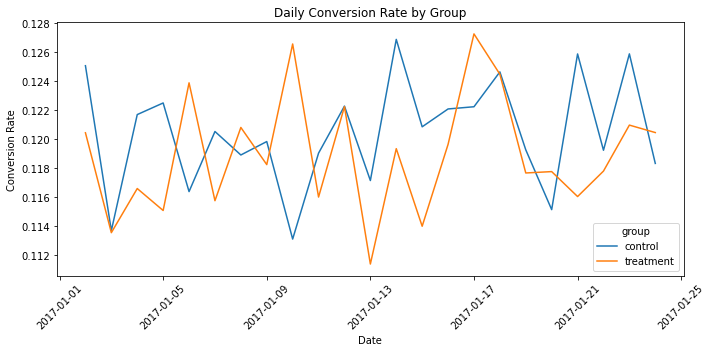

In [27]:
plt.figure(figsize=(10,5))
sns.lineplot(data=daily, x="date", y="converted", hue="group")
plt.title("Daily Conversion Rate by Group")
plt.xlabel("Date")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Even though there are a lot of fluctuations, the treatment underperforms control across most of the experiment days, with no consistent sign of improvement over time.

# Confidence Interval

Question
What is the plausible range of the true treatment effect?

Why we are doing this
A p-value only tells us whether the result is statistically significant. A confidence interval helps answer:
- How uncertain is the estimate?
- Could the real effect be positive, negative, or near zero?
- How wide is the range of likely outcomes?

In [28]:
control_n = len(control)
treatment_n = len(treatment)

control_conv = control["converted"].sum()
treatment_conv = treatment["converted"].sum()

control_cr = control["converted"].mean()
treatment_cr = treatment["converted"].mean()

diff = treatment_cr - control_cr

se = np.sqrt(
    (control_cr * (1 - control_cr) / control_n) +
    (treatment_cr * (1 - treatment_cr) / treatment_n)
)

z = 1.96  # 95% confidence
ci_lower = diff - z * se
ci_upper = diff + z * se

print("Difference in conversion:", diff)
print("95% CI:", (ci_lower, ci_upper))

Difference in conversion: -0.0014795997940775518
95% CI: (-0.0038241393292898045, 0.0008649397411347008)


95% confidence interval includes zero: The observed negative lift is not precise enough to conclude that the treatment truly harms performance.

# Visualizations

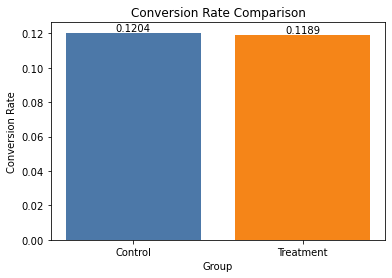

In [30]:
#Conversion rates for both groups
plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Control", "Treatment"],
    [control_cr, treatment_cr],
    color=["#4C78A8", "#F58518"]
)

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             round(yval, 4),
             ha='center', va='bottom')

plt.title("Conversion Rate Comparison")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")

plt.show()

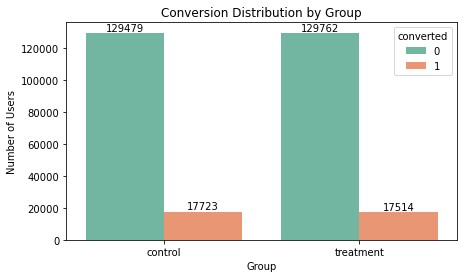

In [31]:
#Conversion distribution
plt.figure(figsize=(7,4))

ax = sns.countplot(data=df, x="group", hue="converted", palette="Set2")

# Add labels
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Conversion Distribution by Group")
plt.xlabel("Group")
plt.ylabel("Number of Users")

plt.show()

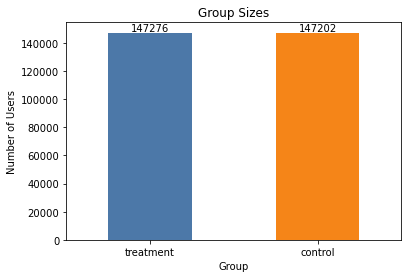

In [32]:
#Sample size for both groups
plt.figure(figsize=(6,4))

ax = df["group"].value_counts().plot(
    kind="bar",
    color=["#4C78A8", "#F58518"]
)

# Add labels
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Group Sizes")
plt.xlabel("Group")
plt.ylabel("Number of Users")

plt.xticks(rotation=0)
plt.show()

# Conclusion

Observations:

1. Treatment did not improve conversion
2. Observed lift is negative
3. Result is not statistically significant
4. Confidence interval shows uncertainty around the effect
5. The effect is not practically compelling
6. Daily trend does not show a convincing improvement over time

The current experiment does not justify rollout. The treatment shows a negative directional signal without statistical evidence of improvement. The next step should be iteration and re-testing, not deployment.